# Import libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from theatre_book_helpers.data_cleaning import (
to_snake_case,
drop_nan_index,
drop_unnamed_cols,
drop_sparse_cols,
clean_date_of_surgery,
drop_invalid_dates,
clean_name_cols,
clean_age,
rename_staff,
clean_text_cols,
clean_categoricals,
clean_time_cols
)

In [2]:
base_dir ="../Nkhoma_data/theatre_book_data"
files = [
    f for f in os.listdir(base_dir)
    if "clean" not in f.lower()
    and "ipynb_checkpoints" not in f.lower()
]

dfs = []

for file in files:
    path = f"{base_dir}/{file}"
    df = pd.read_excel(path, engine="openpyxl")

    # skip if Theatre Book column is missing (based on first column header)
    first_col = df.columns[0]
    if "theatre book" not in str(first_col).lower():
        print(f"Skipping {file}: no Theatre Book column")
        continue

    # normalize the ID column name FIRST
    df = df.rename(columns={first_col: "theatre_book_index"})
    df = to_snake_case(df)
    df = drop_nan_index(df)
    df = drop_unnamed_cols(df)
    dfs.append(df)

Skipping Old Theatre Books.xlsx: no Theatre Book column


In [3]:
df = pd.concat(dfs, ignore_index=True)

In [4]:
df = drop_sparse_cols(df)
df = clean_date_of_surgery(df)
df = drop_invalid_dates(df)
df = clean_name_cols(df)
df = clean_age(df)
df = clean_age(df)
df = clean_categoricals(df)
df = rename_staff(df)
df = clean_time_cols(df)


In [25]:
df

,theatre_book_index,date_of_surgery,first_name,last_name,age_years,sex,village,surgeon,1st_assistent_instructor,2nd_assistent,...,procedure_free_text,histology,starting_time,finishing_time,urgency,surgery_severity,asascore,year_of_birth,operation_time_minutes,year
0,220001,2022-01-01,ELIFA,SUMATI,26,F,Nkhonde,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1997.0,NaT,2022
1,220002,2022-01-01,SIYATU,ISAAC,27,F,Mozambique,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1996.0,NaT,2022
2,220003,2022-01-02,LONESS,MAPEMPHERO,25,F,Chembe,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1998.0,NaT,2022
3,220004,2022-01-03,SAIZI,NEDSON,48,M,Chilikumanda,Limbe,Caleb,NaN,...,Small bowel resection and end-to-end anastamosis,No,NaT,NaT,Emergency,Major,ASA 3,1975.0,NaT,2022
4,220005,2022-01-03,BEATRICE,HEZEKIA,26,F,Mazengera,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1997.0,NaT,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5797,232130,2023-12-30,DAMISON,HEZEKIA,16,M,DETE,Thoko,NaN,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,2007.0,NaT,2023
5798,232131,2023-12-31,STELLA,CHIMWENJE,28,F,KACHERE,Obs/Gyn,Obs/Gyn,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,1995.0,NaT,2023
5799,232132,2023-12-31,TANKHULENI,PATRICK,20,F,CHIMANGO,Obs/Gyn,Obs/Gyn,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,2003.0,NaT,2023
5800,232133,2023-12-31,ESINATI,LUSITIKO,19,F,KALONGA,Obs/Gyn,Obs/Gyn,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,2004.0,NaT,2023


In [5]:
df1 = df[['theatre_book_index','surgeon','main_procedure_category','date_of_surgery']]
df2 = df[['theatre_book_index', '1st_assistent_instructor','main_procedure_category','date_of_surgery']]
df2 = df2.rename(columns={"1st_assistent_instructor": "surgeon"})
df3 = df[['theatre_book_index', '2nd_assistent','main_procedure_category','date_of_surgery']]
df3 = df3.rename(columns={"2nd_assistent": "surgeon"})
df_all = pd.concat([df1, df2, df3], ignore_index=True)

In [6]:
df_all

,theatre_book_index,surgeon,main_procedure_category,date_of_surgery
0,220001,Obs/Gyn,C/S,2022-01-01
1,220002,Obs/Gyn,C/S,2022-01-01
2,220003,Obs/Gyn,C/S,2022-01-02
3,220004,Limbe,Other,2022-01-03
4,220005,Obs/Gyn,C/S,2022-01-03
...,...,...,...,...
17401,232130,NaN,Other,2023-12-30
17402,232131,NaN,Other,2023-12-31
17403,232132,NaN,Other,2023-12-31
17404,232133,NaN,Other,2023-12-31


In [7]:
df_all["procedure_label"] = pd.NA

mask_endoscopy = (
    df_all["main_procedure_category"]
    .astype("string")
    .str.lower()
    .str.contains(r"\begd\b|colonoscopy|coloscopy", regex=True, na=False)
)

df_all.loc[mask_endoscopy, "procedure_label"] = "Endoscopy"
df_all.loc[~mask_endoscopy, "procedure_label"] = "Surgery"

# optional: keep NA where main_procedure_category is NA
df_all.loc[df_all["main_procedure_category"].isna(), "procedure_label"] = pd.NA

In [8]:
df_all["surgeon_label"] = (
    df_all["surgeon"].astype("string")
    + "_"
    + df_all["procedure_label"].astype("string")
)

# Surgeries per surgeon

In [9]:
surgeries_per_surgeon = (
    df_all
    .dropna(subset=["surgeon_label"])
    .groupby("surgeon_label")
    .size()
    .reset_index(name="total_surgeries")
    .sort_values("total_surgeries", ascending=False)
)

In [10]:
surgeries_per_surgeon = surgeries_per_surgeon[
    ~surgeries_per_surgeon["surgeon_label"].isin(["Obs/Gyn", "Other"])
]
surgeries_per_surgeon[["surgeon", "type_of_procedure"]] = (
    surgeries_per_surgeon["surgeon_label"]
    .str.split("_", n=1, expand=True)
)

In [11]:
surgeries_per_surgeon = surgeries_per_surgeon[
    ~surgeries_per_surgeon["surgeon"].isin(["Obs/Gyn", "Other"])
]

In [12]:
# compute total per surgeon
total_df = (
    surgeries_per_surgeon
    .groupby("surgeon", as_index=False)["total_surgeries"]
    .sum()
)

total_df["type_of_procedure"] = "Total"
plot_df = pd.concat(
    [surgeries_per_surgeon, total_df],
    ignore_index=True
)

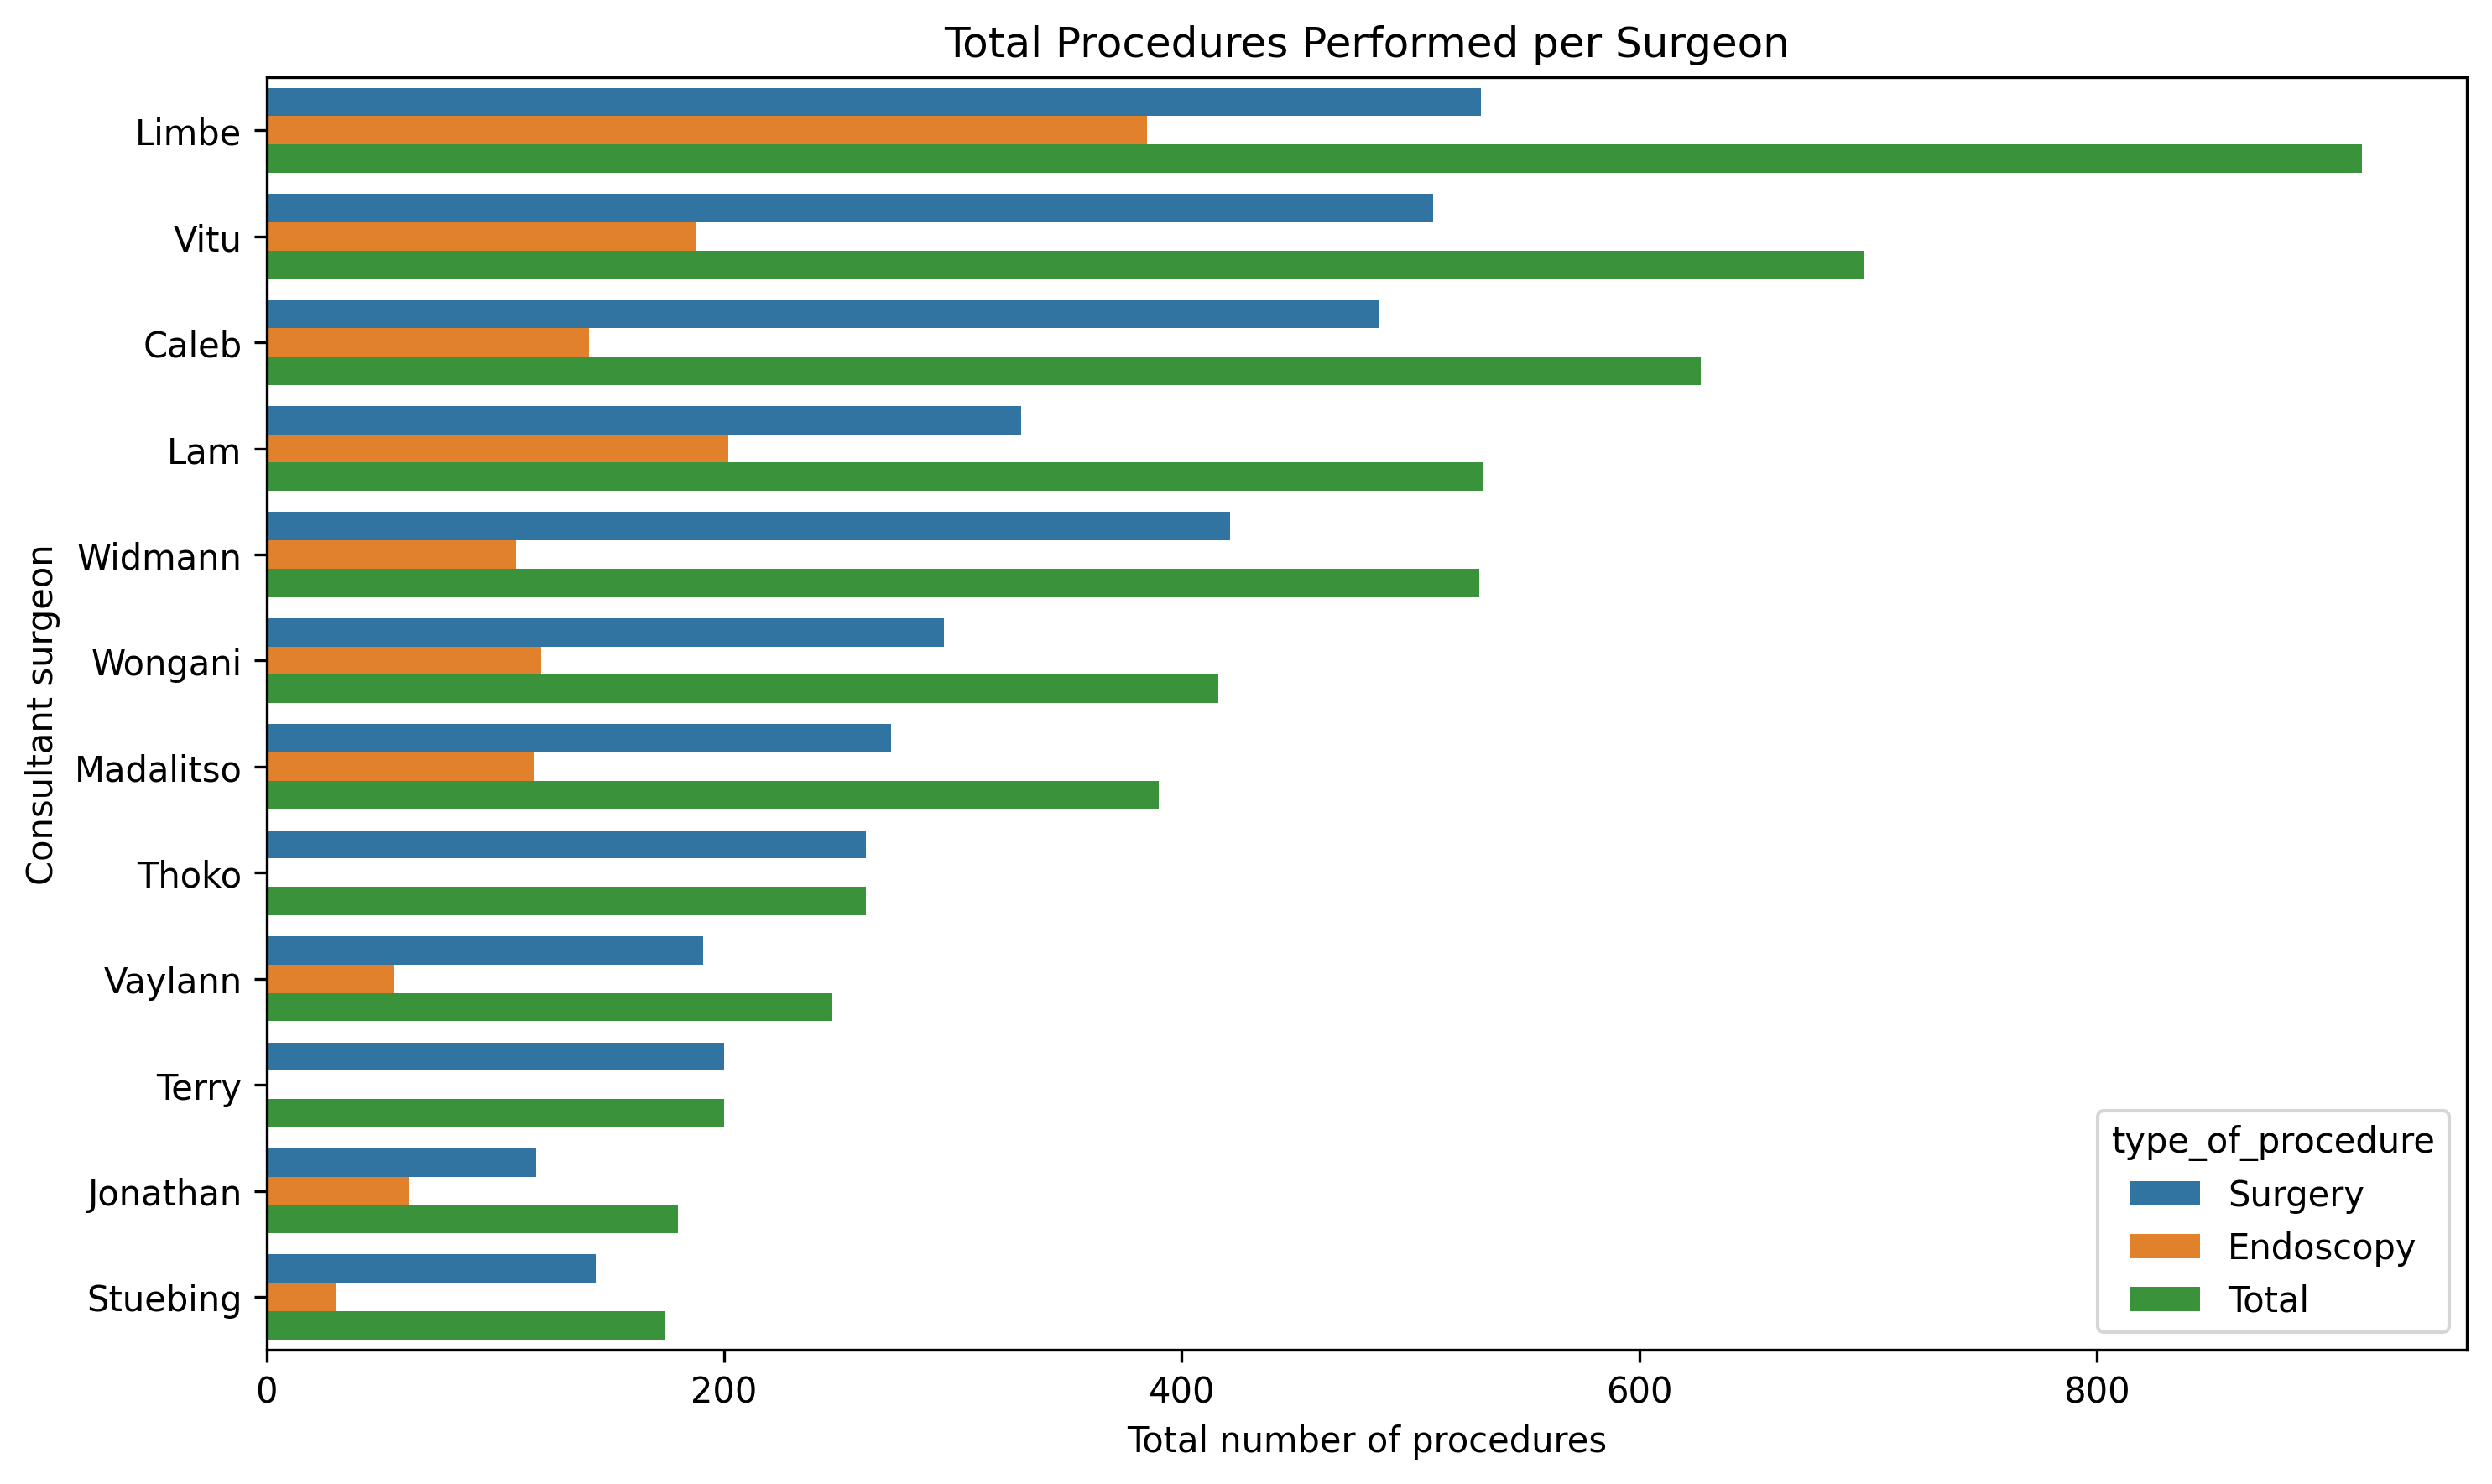

In [13]:
plt.figure(figsize=(10, 6), dpi=300)

sns.barplot(
    data=plot_df,
    y="surgeon",
    x="total_surgeries",
    hue="type_of_procedure",
    order=plot_df.groupby("surgeon")["total_surgeries"]
           .sum()
           .sort_values(ascending=False)
           .index,
)

plt.xlabel("Total number of procedures")
plt.ylabel("Consultant surgeon")
plt.title("Total Procedures Performed per Surgeon")

plt.tight_layout()
plt.savefig(
    "procedures_performed_per_surgeon.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [14]:
# extract year
df_filtered = df_all[
    ~df_all["surgeon"].isin(["Other", "Obs/Gyn"])
]
df_filtered["year"] = df_filtered["date_of_surgery"].dt.year

# count surgeries per year per surgeon
yearly_counts = (
    df_filtered
    .dropna(subset=["surgeon"])          # optional: drop missing surgeons
    .groupby(["year", "surgeon"])
    .size()
    .reset_index(name="n_surgeries")
)

/tmp/ipykernel_11528/2284862864.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["year"] = df_filtered["date_of_surgery"].dt.year


In [15]:
names = list(yearly_counts["surgeon"].unique())

list_order = [
    "Limbe", "Vaylann", "Lam", "Stuebing", "Widmann",
    "Widmann", "Caleb", "Vitu", "Wongani",
    "Madalitso", "Jonathan", "Thoko", "Thoko", "Terry"
]

# remove duplicates, keep order, and keep only valid names
hue_order = []
for s in list_order:
    if s in names and s not in hue_order:
        hue_order.append(s)

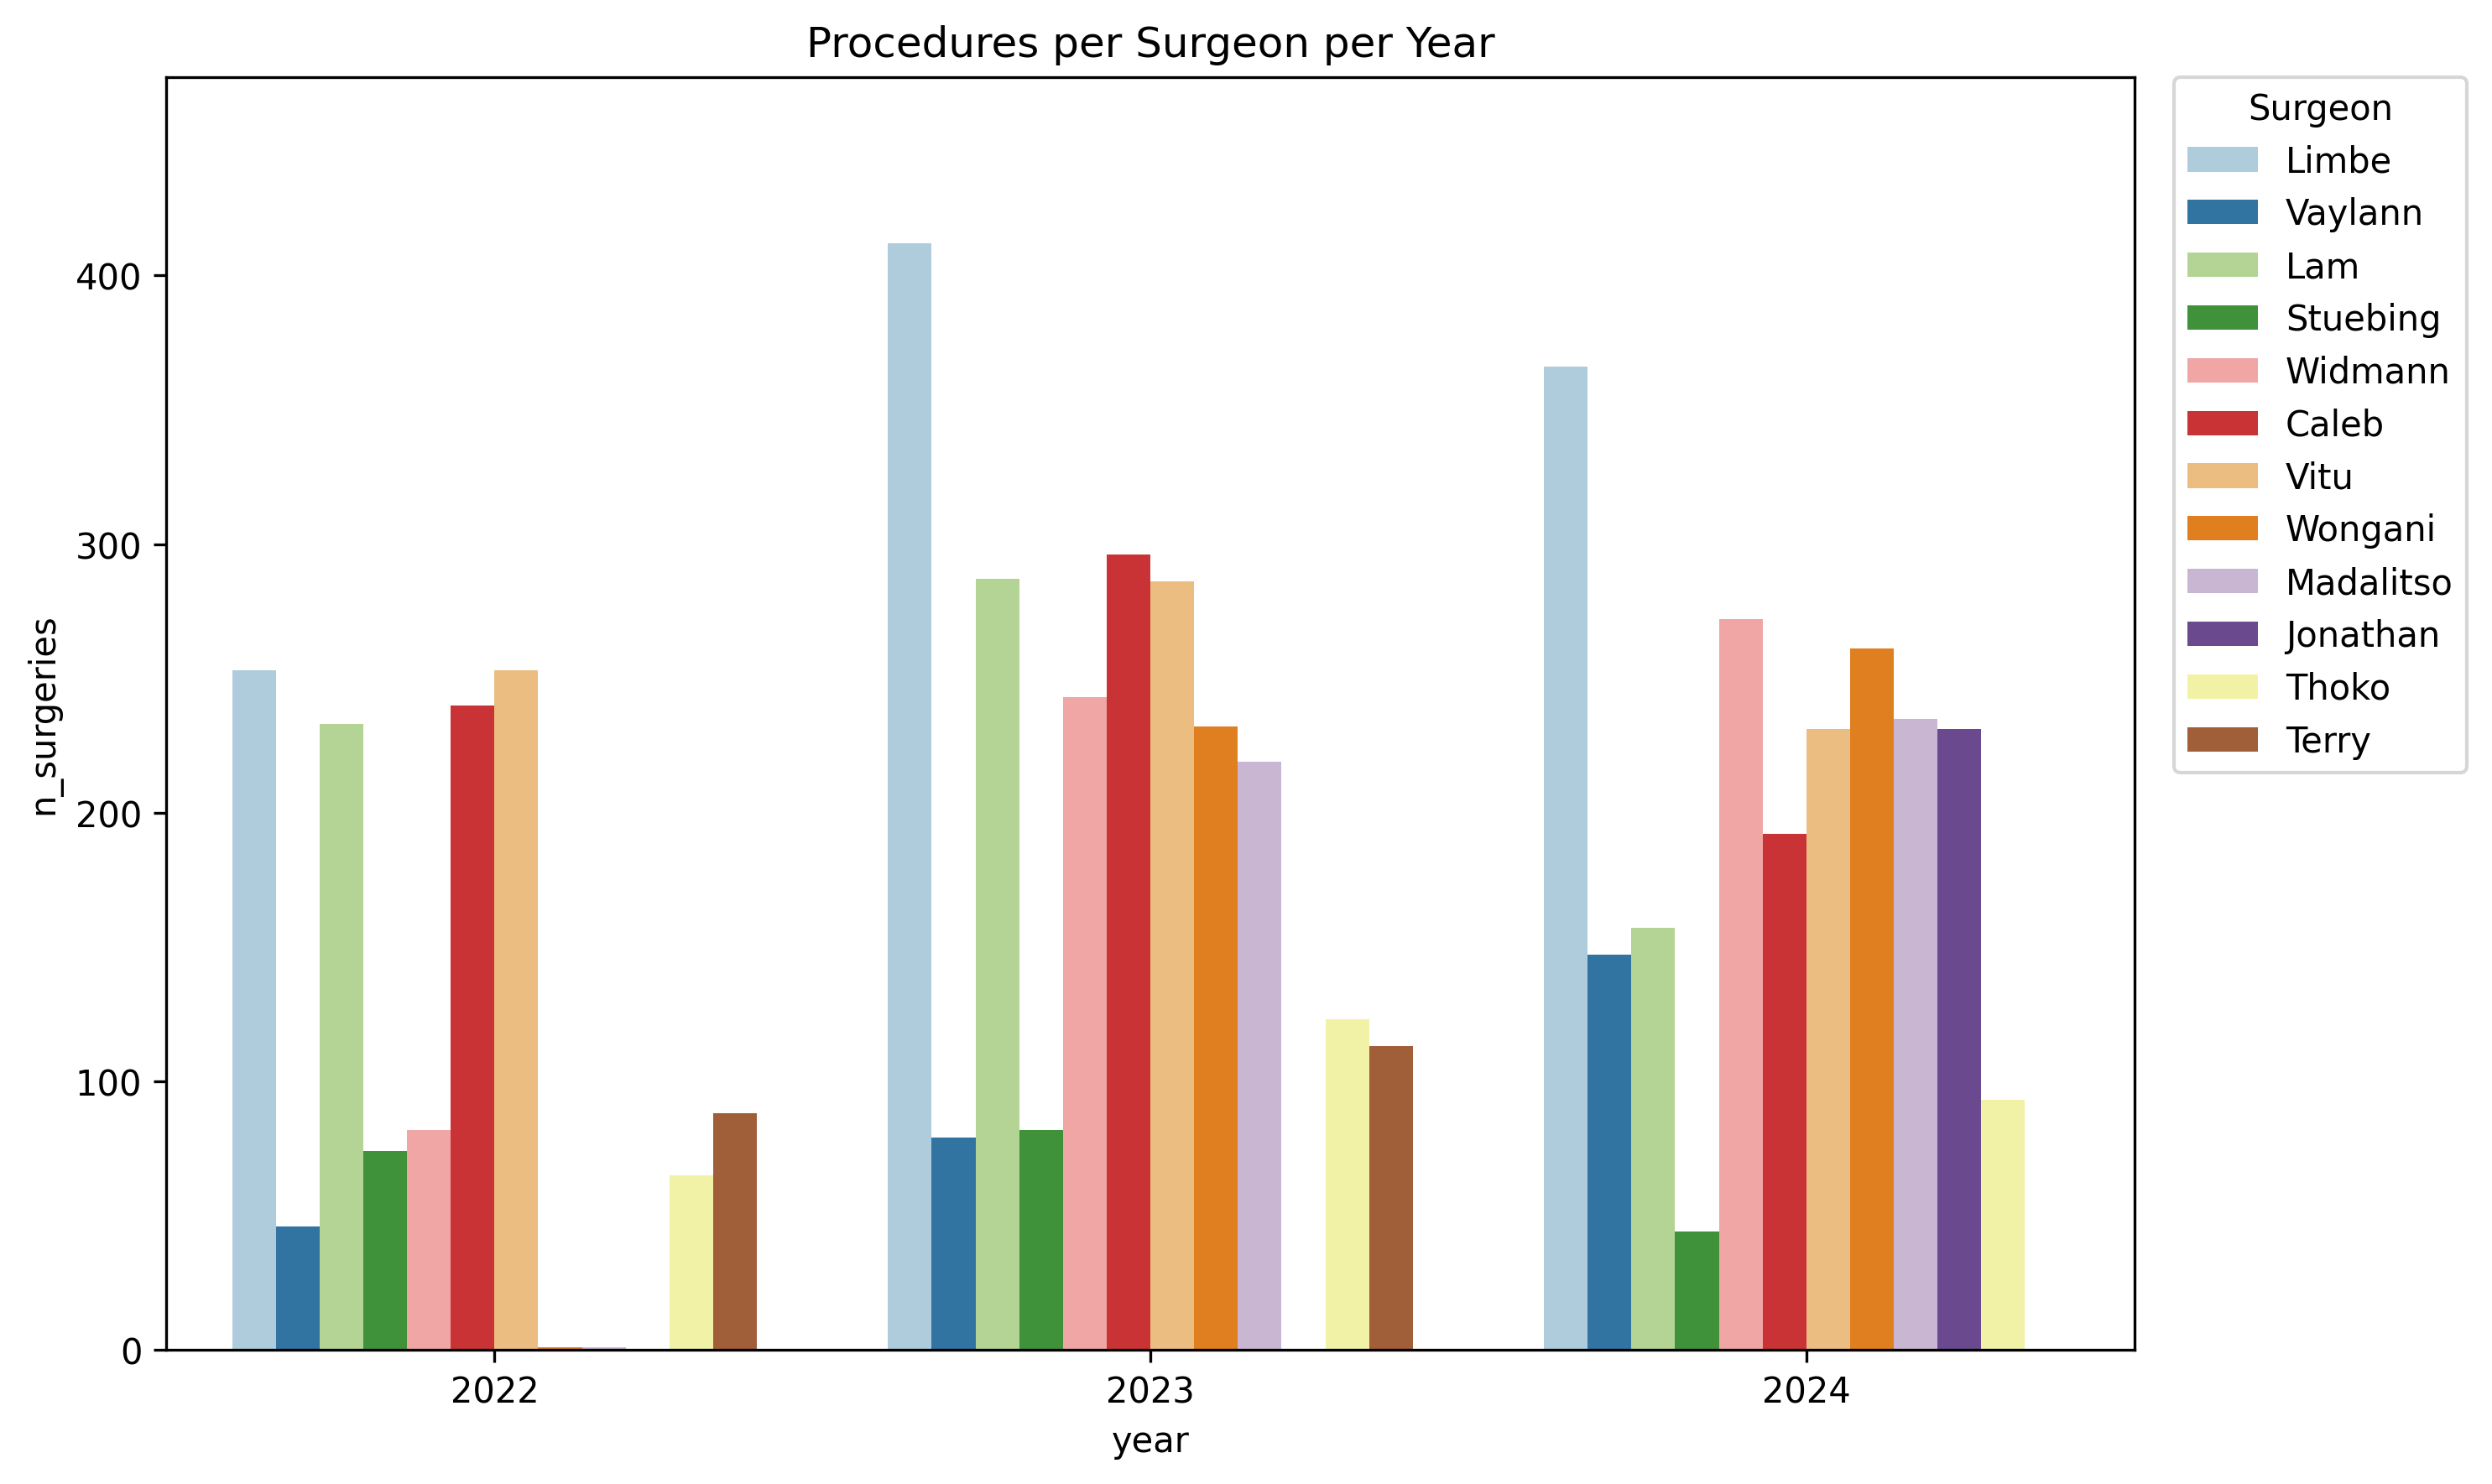

In [16]:
plt.figure(figsize=(10, 6), dpi=300)

ax = sns.barplot(
    data=yearly_counts,
    x="year",
    y="n_surgeries",
    hue="surgeon",
    hue_order=hue_order,
    palette="Paired"
)

# add ~15% headroom
y_max = yearly_counts["n_surgeries"].max()
ax.set_ylim(0, y_max * 1.15)

ax.set_title("Procedures per Surgeon per Year")

plt.legend(
    title="Surgeon",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.savefig("procedures_per_surgeon_per_year.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
names = list(yearly_counts.surgeon.unique())
list_order = ["Limbe", "Vaylann", "Lam", "Stuebing", "Widmann","Widmann","Caleb", "Vitu","Wongani", "Madalitso", "Jonathan", "Thoko", "Thoko","Terry"]

In [18]:
# proportions per surgeon from plot_df (ignore the 'Total' rows if present)
type_totals = (
    plot_df[plot_df["type_of_procedure"].isin(["Surgery", "Endoscopy"])]
    .groupby(["surgeon", "type_of_procedure"], as_index=False)["total_surgeries"]
    .sum()
)

props = (
    type_totals
    .pivot(index="surgeon", columns="type_of_procedure", values="total_surgeries")
    .fillna(0)
)

# proportion of surgery for each surgeon (avoid divide-by-zero)
props["p_surgery"] = np.where(
    (props.get("Surgery", 0) + props.get("Endoscopy", 0)) > 0,
    props.get("Surgery", 0) / (props.get("Surgery", 0) + props.get("Endoscopy", 0)),
    np.nan
)

# merge proportions into yearly_counts
tmp = yearly_counts.merge(props["p_surgery"], left_on="surgeon", right_index=True, how="left")

# estimate split
tmp["n_surgery_est"] = (tmp["n_surgeries"] * tmp["p_surgery"]).round().astype("Int64")
tmp["n_endoscopy_est"] = (tmp["n_surgeries"] - tmp["n_surgery_est"]).astype("Int64")

# long format for plotting
yearly_type_counts_est = pd.concat([
    tmp[["year", "surgeon"]].assign(type_of_procedure="Surgery",  n_surgeries=tmp["n_surgery_est"]),
    tmp[["year", "surgeon"]].assign(type_of_procedure="Endoscopy", n_surgeries=tmp["n_endoscopy_est"]),
], ignore_index=True)


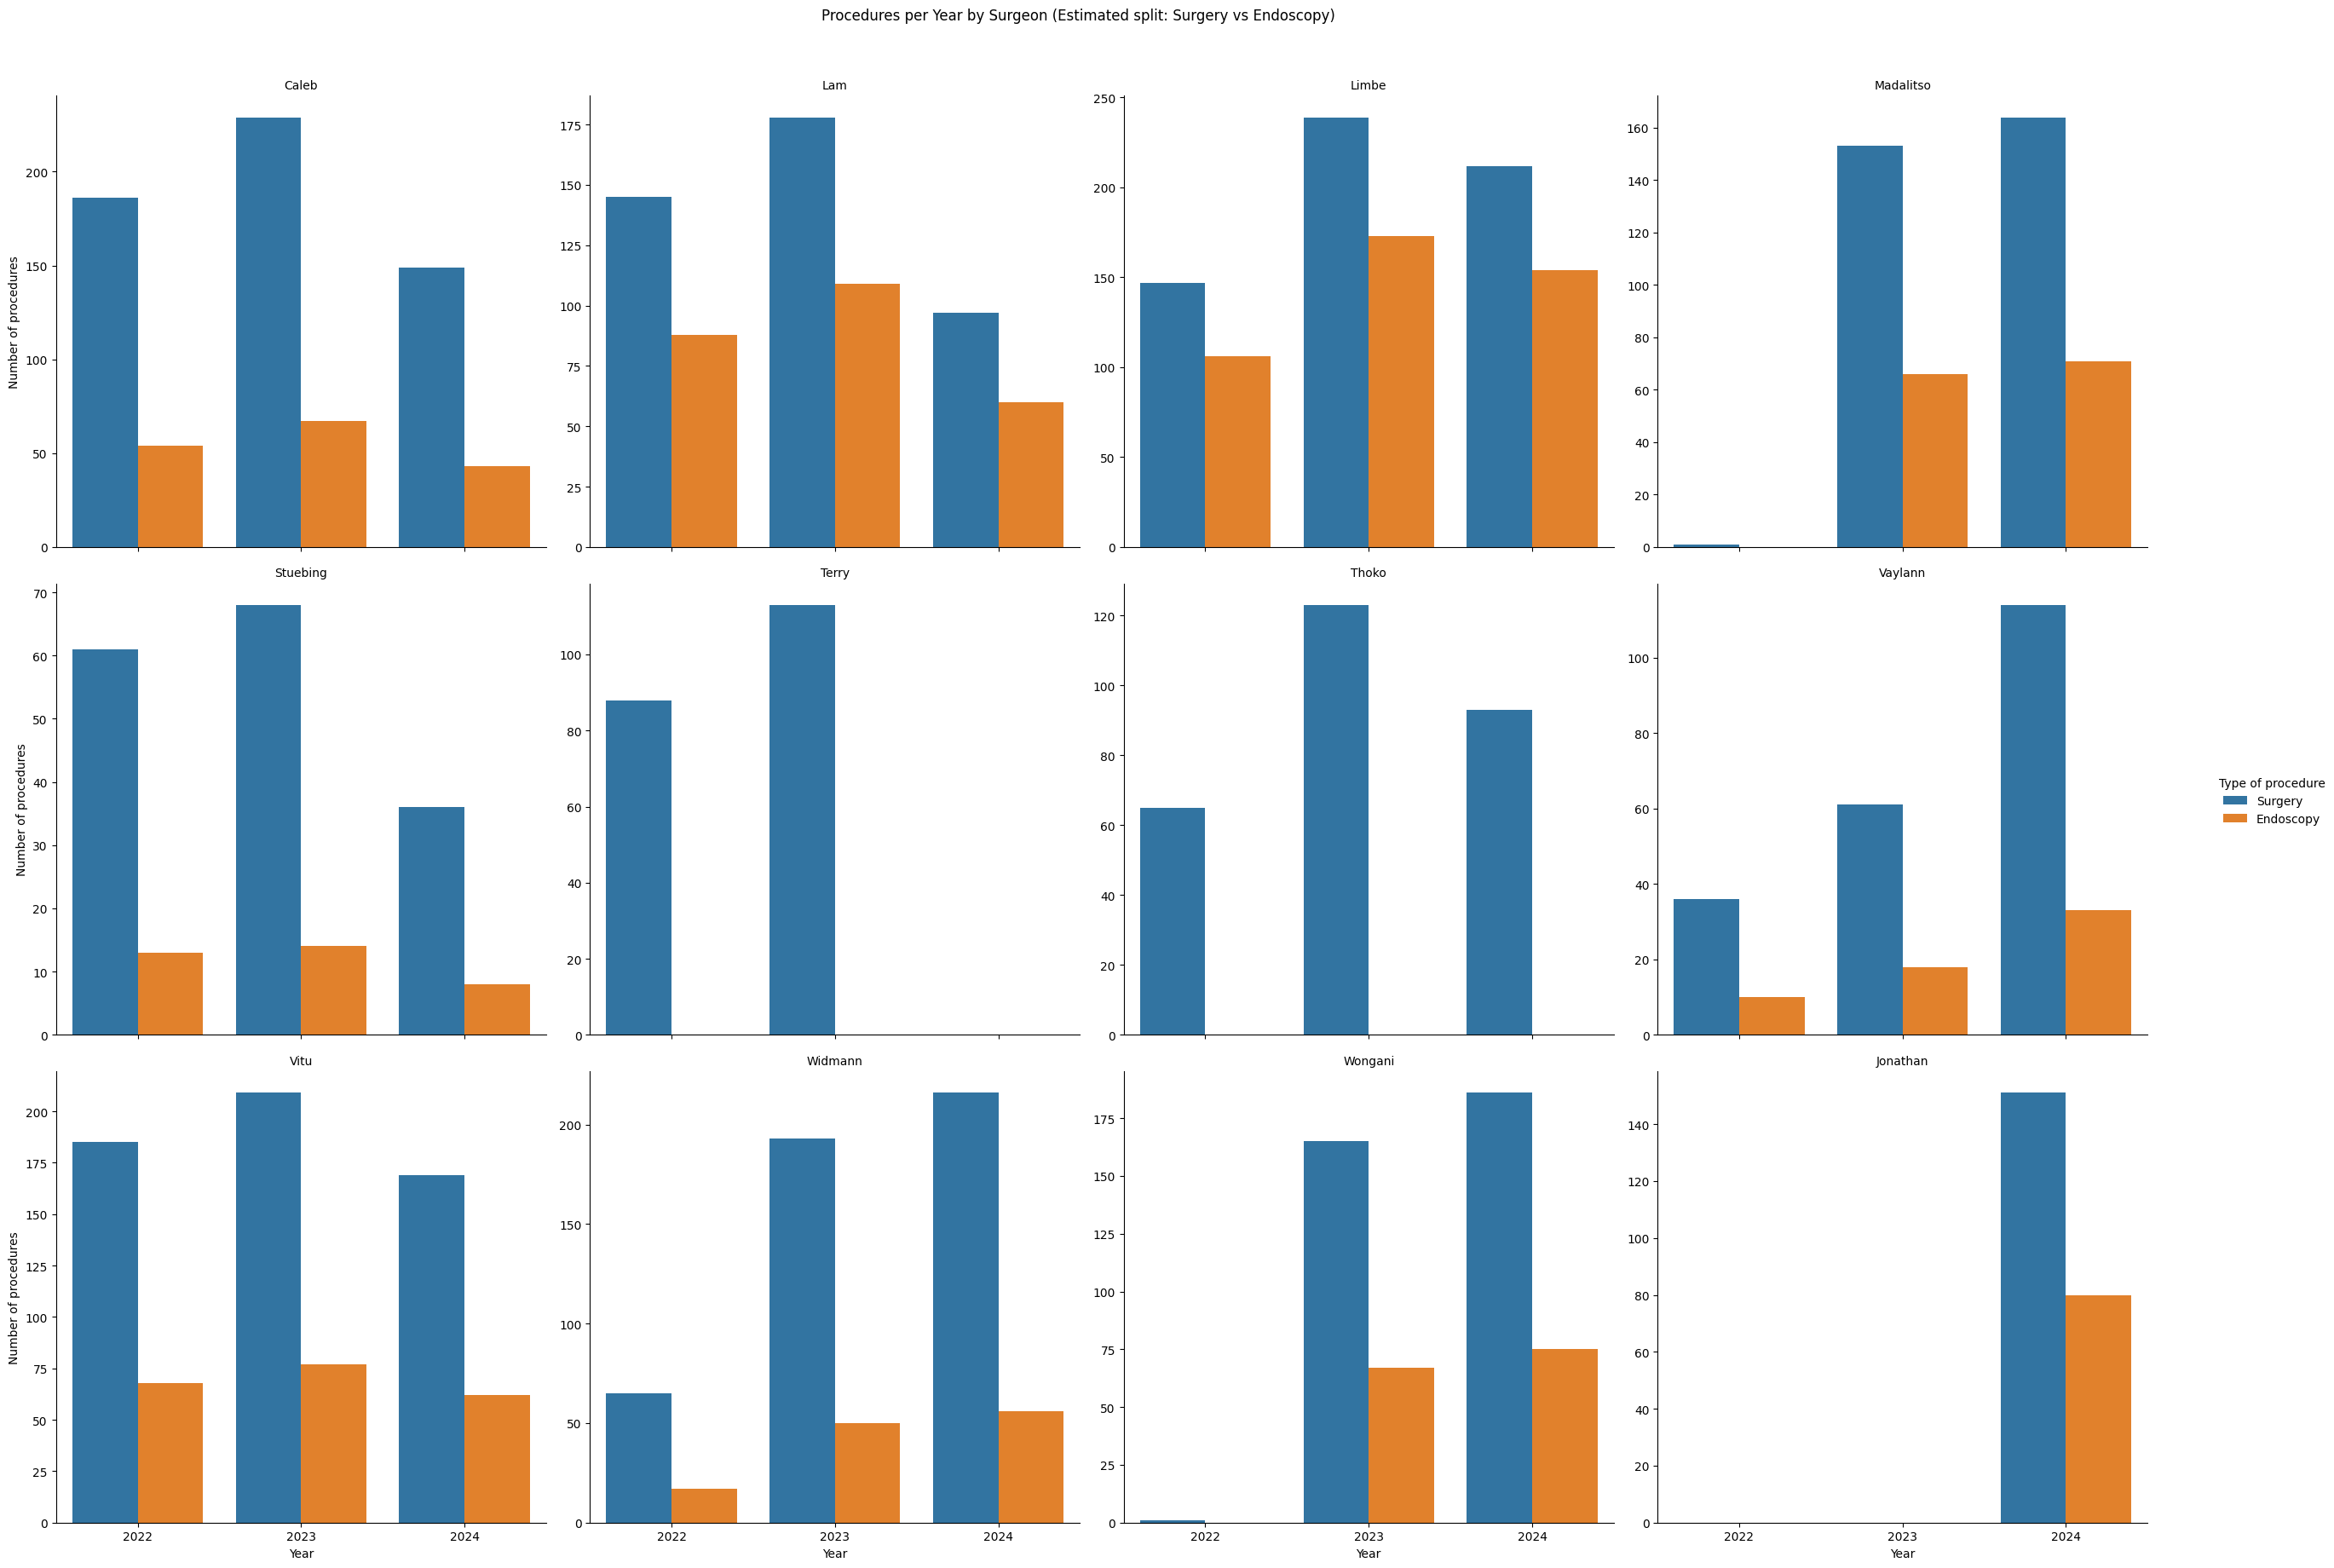

In [19]:
g = sns.catplot(
    data=yearly_type_counts_est,
    x="year",
    y="n_surgeries",
    hue="type_of_procedure",
    col="surgeon",
    kind="bar",
    col_wrap=4,
    height=6,
    sharey=False
)

g.set_axis_labels("Year", "Number of procedures")
g.set_titles("{col_name}")

g.fig.suptitle("Procedures per Year by Surgeon (Estimated split: Surgery vs Endoscopy)", y=1.02)

# move legend outside
if g._legend is not None:
    g._legend.set_title("Type of procedure")
    g._legend.set_bbox_to_anchor((1.02, 0.5))
    g._legend.set_loc("center left")

plt.tight_layout()
plt.savefig("procedures_per_surgeon_per_year_by_type.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# extract year
df["year"] = pd.to_datetime(df["date_of_surgery"], errors="coerce").dt.year

surgeries_per_surgeon_year = (
    df
    .dropna(subset=["surgeon", "year"])
    .groupby(["surgeon", "year"])
    .size()
    .reset_index(name="surgeries")
)

# average surgeries per year per surgeon
avg_per_year = (
    surgeries_per_surgeon_year
    .groupby("surgeon")["surgeries"]
    .mean()
    .reset_index(name="avg_surgeries_per_year")
    .sort_values("avg_surgeries_per_year", ascending=False)
)


In [21]:
# ensure year exists
df["year"] = pd.to_datetime(
    df["date_of_surgery"], errors="coerce"
).dt.year

year_surgeon_counts = (
    df
    .dropna(subset=["surgeon", "year"])
    .groupby(["year", "surgeon"])
    .size()
    .reset_index(name="surgeries")
)


In [22]:
surgeons = sorted(year_surgeon_counts["surgeon"].unique())

palette = dict(
    zip(
        surgeons,
        sns.color_palette("tab20", n_colors=len(surgeons))
    )
)


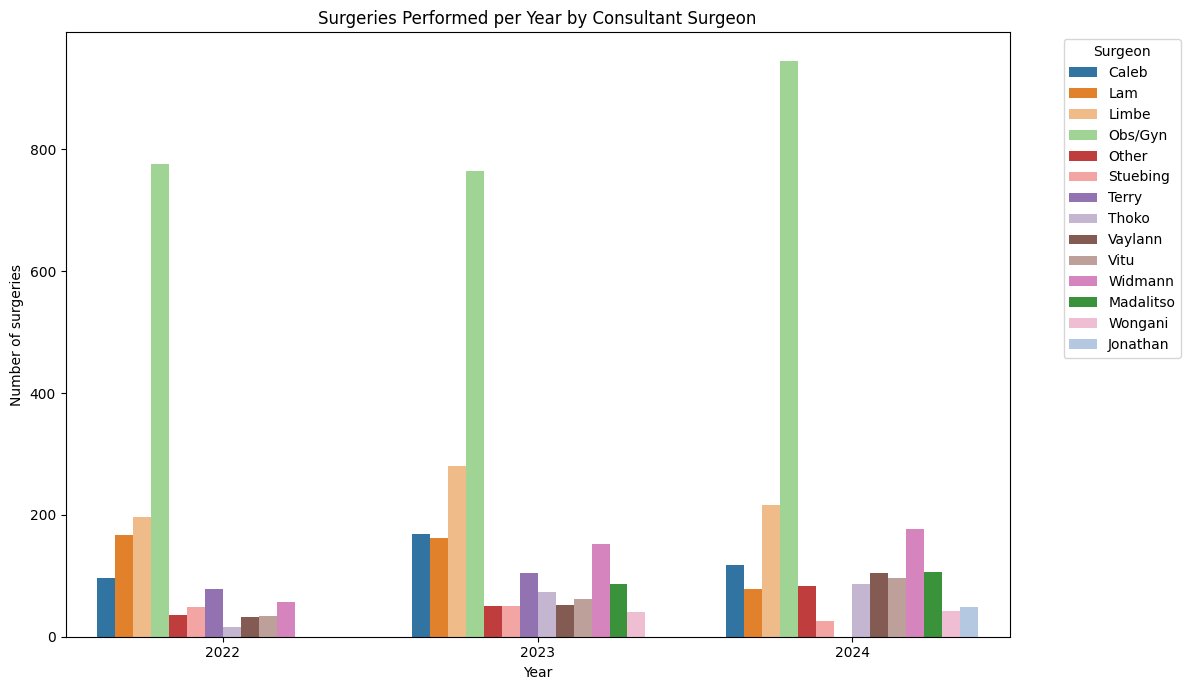

In [23]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=year_surgeon_counts,
    x="year",
    y="surgeries",
    hue="surgeon",
    palette=palette,
)

plt.xlabel("Year")
plt.ylabel("Number of surgeries")
plt.title("Surgeries Performed per Year by Consultant Surgeon")

plt.legend(
    title="Surgeon",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [24]:
df.to_excel(f"{base_dir}/combined_clean.xlsx", index=False, engine="openpyxl")
print(f"Saved {len(df)} rows")

Saved 5802 rows


In [26]:
df

,theatre_book_index,date_of_surgery,first_name,last_name,age_years,sex,village,surgeon,1st_assistent_instructor,2nd_assistent,...,procedure_free_text,histology,starting_time,finishing_time,urgency,surgery_severity,asascore,year_of_birth,operation_time_minutes,year
0,220001,2022-01-01,ELIFA,SUMATI,26,F,Nkhonde,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1997.0,NaT,2022
1,220002,2022-01-01,SIYATU,ISAAC,27,F,Mozambique,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1996.0,NaT,2022
2,220003,2022-01-02,LONESS,MAPEMPHERO,25,F,Chembe,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1998.0,NaT,2022
3,220004,2022-01-03,SAIZI,NEDSON,48,M,Chilikumanda,Limbe,Caleb,NaN,...,Small bowel resection and end-to-end anastamosis,No,NaT,NaT,Emergency,Major,ASA 3,1975.0,NaT,2022
4,220005,2022-01-03,BEATRICE,HEZEKIA,26,F,Mazengera,Obs/Gyn,NaN,NaN,...,NaN,No,NaT,NaT,NaN,<NA>,NaN,1997.0,NaT,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5797,232130,2023-12-30,DAMISON,HEZEKIA,16,M,DETE,Thoko,NaN,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,2007.0,NaT,2023
5798,232131,2023-12-31,STELLA,CHIMWENJE,28,F,KACHERE,Obs/Gyn,Obs/Gyn,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,1995.0,NaT,2023
5799,232132,2023-12-31,TANKHULENI,PATRICK,20,F,CHIMANGO,Obs/Gyn,Obs/Gyn,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,2003.0,NaT,2023
5800,232133,2023-12-31,ESINATI,LUSITIKO,19,F,KALONGA,Obs/Gyn,Obs/Gyn,NaN,...,NaN,No,NaT,NaT,Emergency,<NA>,NaN,2004.0,NaT,2023
